In [1]:
from keras.utils import image_dataset_from_directory
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from keras import layers,models
import keras
import tensorflow as tf
import numpy as np
from keras.applications.mobilenet_v2 import preprocess_input
from keras.utils import load_img, img_to_array
print(tf.config.list_physical_devices("GPU"))

I0000 00:00:1784355251.944022    7850 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784355253.476875    7850 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784355256.267770    7850 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
AUTOTUNE = tf.data.AUTOTUNE

image_height = 224
image_width = 224
IMG_SIZE = (image_height,image_width)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    "untrack/17flowerclasses/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(train_ds.class_names)
print(train_ds)

class_name = train_ds.class_names

Found 1190 files belonging to 17 classes.


I0000 00:00:1784355264.540648    7850 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4163 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


['Bluebell', 'ButterCup', 'ColtsFoot', 'Cowslip', 'Crocus', 'Daffodil', 'Daisy', 'Dandelion', 'Fritillary', 'Iris', 'LilyValley', 'Pansy', 'Snowdrop', 'Sunflower', 'Tigerlily', 'WindFlower', 'tulip']
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [3]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

In [4]:

test_ds = image_dataset_from_directory(
    "untrack/17flowerclasses/test", 
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

print(test_ds.class_names)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 170 files belonging to 17 classes.


['Bluebell', 'ButterCup', 'ColtsFoot', 'Cowslip', 'Crocus', 'Daffodil', 'Daisy', 'Dandelion', 'Fritillary', 'Iris', 'LilyValley', 'Pansy', 'Snowdrop', 'Sunflower', 'Tigerlily', 'WindFlower', 'tulip']


In [5]:
data_dir = Path("untrack/17flowerclasses/")

In [6]:
train_data_dir = Path(str(data_dir)+"/train")
image_count = len(list(train_data_dir.glob('*/*.jpg')))
image_count

1190

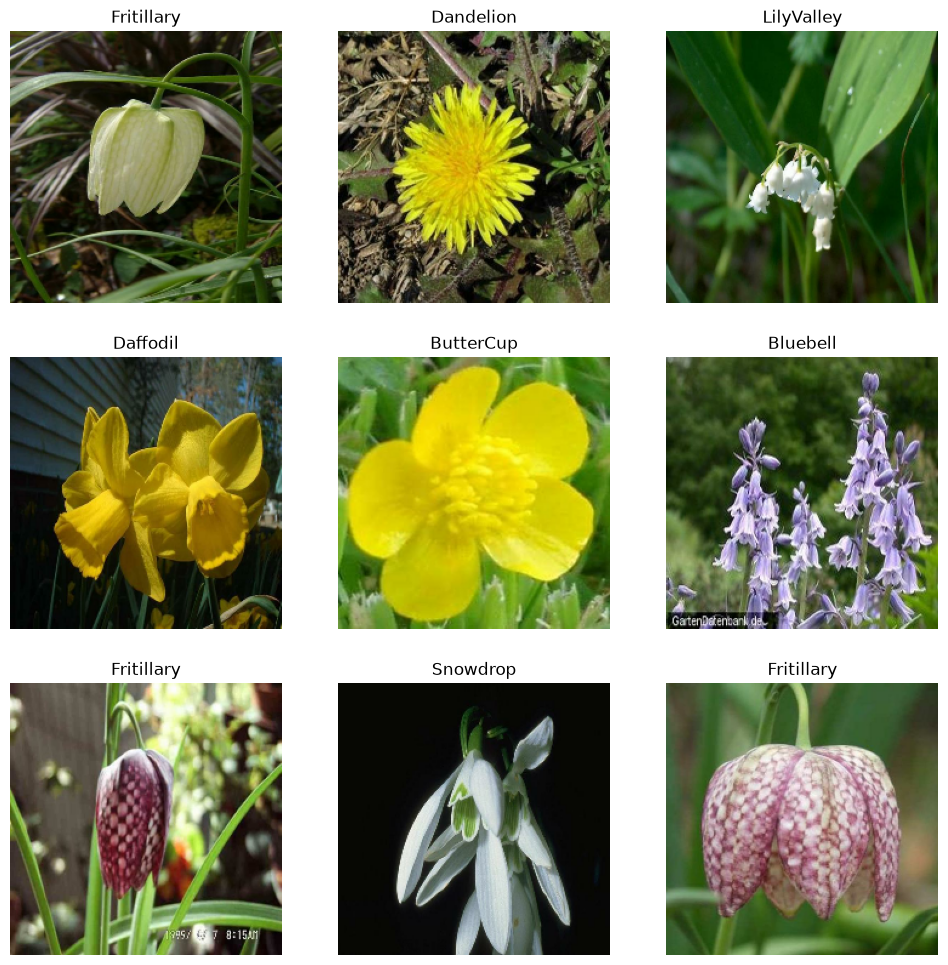

In [7]:
plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_name[labels[i]])
        plt.axis("off")

plt.show()
        

In [8]:
num_class = len(class_name)
image_height = 224
image_width = 224

In [9]:
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [10]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.2),
        layers.RandomContrast(0.2)    
    ]
)

In [11]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [12]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

In [12]:
base_model = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [13]:
base_model.trainable = False

In [14]:
preprocess = keras.applications.mobilenet_v2.preprocess_input

In [15]:
model = keras.Sequential([
    layers.Resizing(224,224),

    layers.Lambda(
        keras.applications.mobilenet_v2.preprocess_input
    ),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(17)
])

In [16]:
model.layers

[<Resizing name=resizing, built=False>,
 <Lambda name=lambda, built=False>,
 <Functional name=mobilenetv2_1.00_224, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d, built=True>,
 <Dense name=dense, built=False>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense_1, built=False>]

In [17]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [19]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
)

Epoch 1/10


/home/mohammad/miniconda3/envs/tfgpu/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1784355330.425605    8813 service.cc:153] XLA service 0x7f3d74060710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1784355330.425620    8813 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1784355330.526617    8813 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1784355331.174923    8813 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1784355331.246353    8813 dot_

 3/38 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.1042 - loss: 2.8441     

I0000 00:00:1784355343.269273    8813 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 5/38 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.1250 - loss: 2.7007

I0000 00:00:1784355344.076026    8811 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_8299__.119


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.5429 - loss: 1.5308

I0000 00:00:1784355360.271624    8811 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 706ms/step - accuracy: 0.5429 - loss: 1.5308 - val_accuracy: 0.7941 - val_loss: 0.7429
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.8706 - loss: 0.4717 - val_accuracy: 0.8176 - val_loss: 0.6166
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9218 - loss: 0.2785 - val_accuracy: 0.8706 - val_loss: 0.4572
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9622 - loss: 0.1799 - val_accuracy: 0.8529 - val_loss: 0.4192
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.9697 - loss: 0.1357 - val_accuracy: 0.8765 - val_loss: 0.4233
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9824 - loss: 0.0923 - val_accuracy: 0.8824 - val_loss: 0.3527
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9866 - loss: 0.0710 - val_accuracy: 0.8941 - val_loss: 0.3901
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9933 - loss: 0.0503 - val_accuracy: 0.8824 - val_loss: 

In [20]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 17)             │         2,193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,756,469 (10.52 MB)

 Trainable params: 166,161 (649.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 332,324 (1.27 MB)

In [21]:
model.evaluate(test_ds)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8824 - loss: 0.3795


[0.3794686198234558, 0.8823529481887817]

In [23]:
pred = model.predict(test_ds)

6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 476ms/step


In [24]:
model.evaluate(test_ds)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9000 - loss: 0.3537


[0.3536752462387085, 0.8999999761581421]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
----------------------------------------
ColtsFoot
predicted class name 0.788065493106842
True class name ColtsFoot
----------------------------------------
WindFlower
predicted class name 0.998815655708313
True class name WindFlower
----------------------------------------
Bluebell
predicted class name 0.9827123880386353
True class name Bluebell


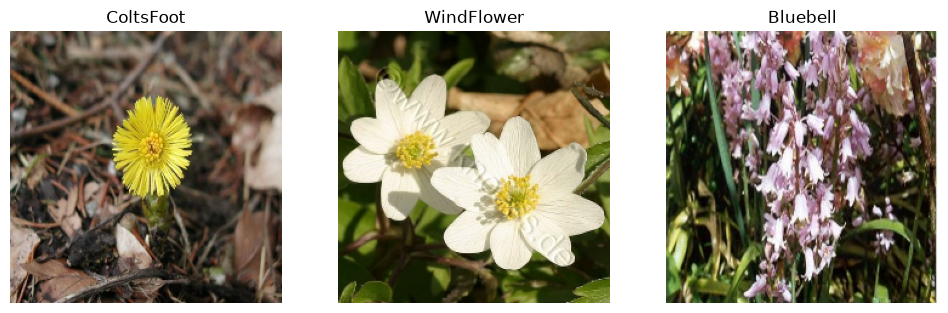

In [42]:
plt.figure(figsize=(12,12))

for images, labels in test_ds.take(1):
    
    image_resized = tf.image.resize(images,size=(224,224))
    preds = model.predict(image_resized)
    
    for i in range(3):
        
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_name[labels[i]])
        plt.axis("off")
        
        
        pred = tf.nn.softmax(preds[i])
        print("----------------------------------------")
        print(class_name[np.argmax(pred)])
        print(f"predicted class name {float(np.max(pred))}")
        print(f"True class name {class_name[labels[i]]}")
    

plt.show()
